STOCK PRICE PREDICTION IN PYTHON WITH PYTORCH

Some questions you might have along the way -:

1. What exactly is a Long Short Term Memory (LSTM)?
    It is a type of Recurrent Neural Network (RNN) that's good at learning from sequences of data (like a list of stock prices over time). Unlike a regular RNN, it has a built-in mechanism for deciding what to remember and what to forget as it reads through the sequence, which helps it pick up on longer-term patterns without getting overwhelmed.

2. Why do we scale the closing prices before training?
    Neural networks learn better when the numbers they see are small and centered around zero, rather than in the hundreds (like real stock prices). We use a `StandardScaler` to shrink the prices down, and later "undo" this transformation (`inverse_transform`) so the predictions make sense again in real dollars.

3. Why do we split the data into 30-day sequences?
    The model can't look at the whole multi-year history at once and reason about it directly. Instead, we give it a sliding window of the last 30 days at a time and ask it to predict the next day, similar to how you might glance at the last month of prices before guessing tomorrow's.

4. Why do we split into training and test sets?
    We train the model on 80% of the sequences so it can learn patterns, then test it on the remaining 20% it has never seen before. This tells us whether the model actually learned something useful, or just memorized the training data.

5. What do `hidden_dim` and `num_layers` mean?
    `hidden_dim` is the size of the LSTM's internal "memory" — a bigger number means it can potentially capture more complex patterns, but also risks overfitting. `num_layers` stacks multiple LSTM layers on top of each other, letting the model learn more abstract patterns, similar to stacking layers in a regular neural network.

6. What is the loss function doing during training?
    `MSELoss` (Mean Squared Error) measures how far off the model's predictions are from the actual prices. During training, the model repeatedly adjusts its internal weights to shrink this error, a process driven by the optimizer (`Adam`).

7. What does RMSE tell us at the end?
    Root Mean Squared Error converts the error back into the same units as the original prices (dollars), giving us an intuitive sense of "on average, how many dollars off was the model?" Lower is better.

8. Is this model actually useful for real trading?
    No — this is a programming exercise to practice working with time-series data and recurrent neural networks. It shouldn't be used to make real investment decisions.

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

In [87]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [88]:
ticker = 'GOOGL'
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

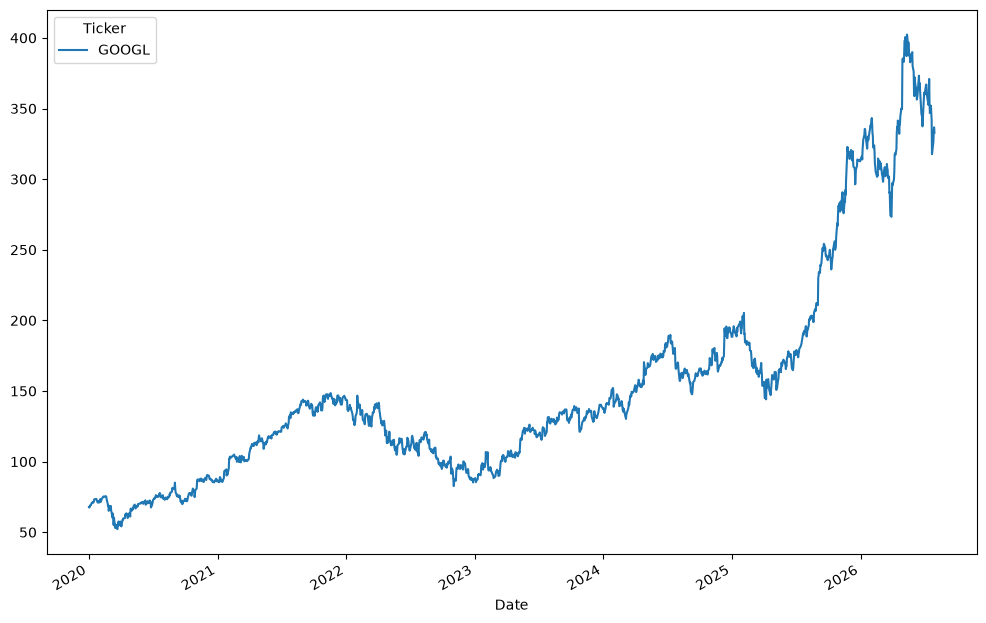

In [89]:
df.Close.plot(figsize=(12,8))

In [90]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])
df.Close

Ticker,GOOGL
Date,
2020-01-02,-1.104831
2020-01-03,-1.109530
2020-01-06,-1.085711
2020-01-07,-1.087483
2020-01-08,-1.080965
...,...
2026-07-24,2.231389
2026-07-27,2.321712
2026-07-28,2.416405


In [91]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [92]:
train_size = int(0.8* len(data)) #80%
x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [93]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self,x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out


In [94]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [95]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [96]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(x_train)
    loss = criterion(y_train_pred, y_train)
    if i % 25 == 0:
        print(i, loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


0 0.3433109223842621
25 0.006245275028049946
50 0.002263925736770034
75 0.0019652543123811483
100 0.0018296311609447002
125 0.0017573026707395911
150 0.0016931432764977217
175 0.0016295029781758785


In [97]:
model.eval()

y_test_pred = model(x_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [98]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:,0], y_test_pred[:, 0])

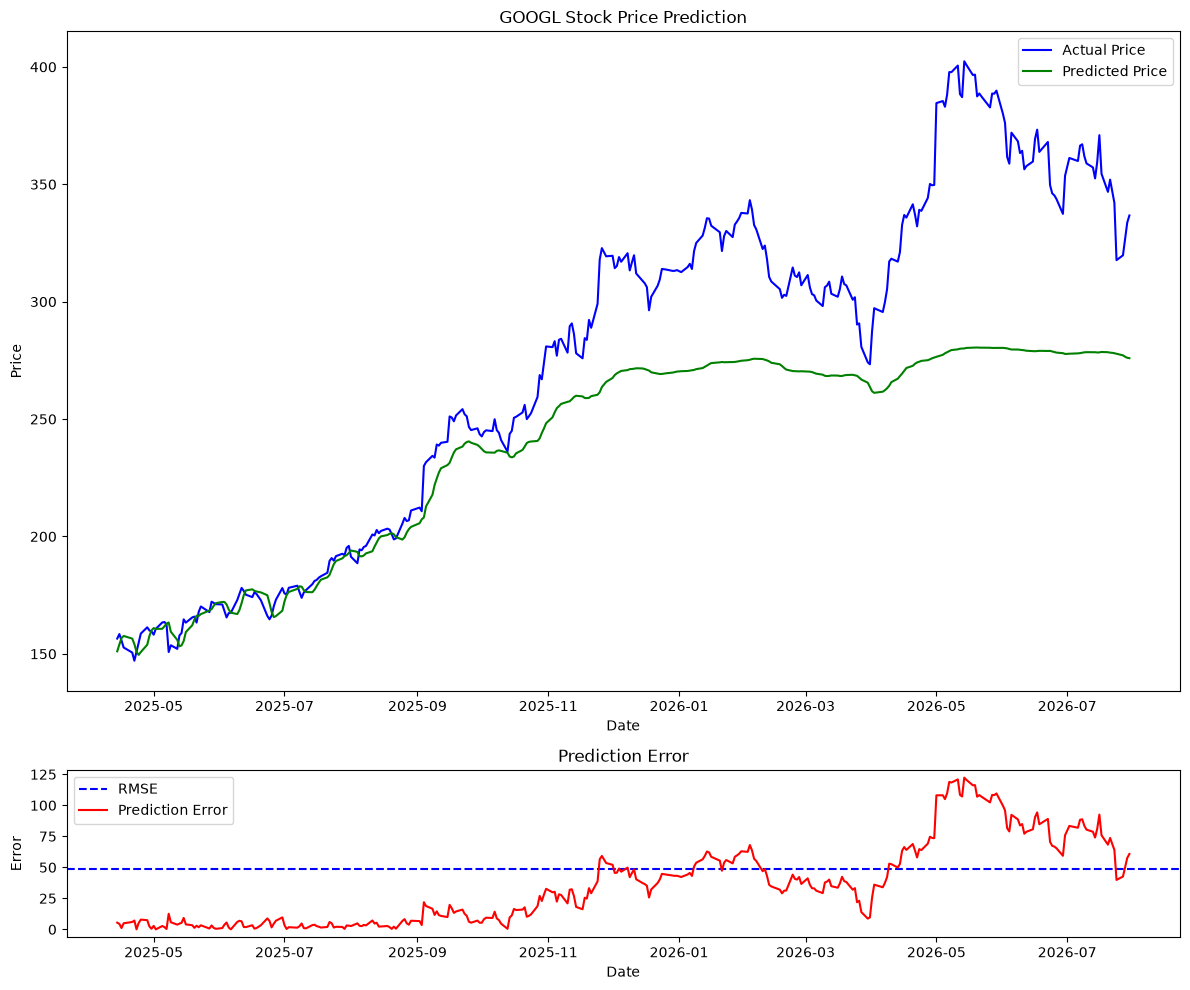

In [99]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')
ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()